---
numbering: false
---

# 3.3: Linear transformations

You may have noticed that, in [Chapter 3.2](03-02.ipynb), we thought of multiplying a matrix by a vector as **transforming** the vector in some describable way. Some matrices stretched our vectors, some rotated them, and some sent them all to a line.

What type of transformation does matrix-vector multiplication describe? To answer that question, we first need to agree on what a **function** is.


In [1]:
from pathlib import Path
import sys
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
if str(_notes_root / 'ch03') not in sys.path:
    sys.path.insert(0, str(_notes_root / 'ch03'))
from friendly_visuals import mapping, transform, projection_line, projection_plane
from chapter3_visuals import save_figure, widget, show_3d


---

## Functions

You have probably seen functions written as $f(x)=x^2$ or $f(x)=2x+1$. In each case, we put a number in and get a number out. But a function's inputs and outputs don't have to be individual numbers!

:::{note} Definition: Function
A **function** $f:A\to B$ is an operation that takes each element of a set $A$ and assigns it exactly one element of a set $B$.

We call $A$ the **domain** and $B$ the **codomain**. If we put in $a\in A$, we write the output as $f(a)\in B$.
:::

For example, suppose $A=\{1,2,3,4,5\}$ and $B=\{1,2,3,4,5\}$. We can define a function just by listing what it does:

| Input $a$ | 1 | 2 | 3 | 4 | 5 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Output $f(a)$ | 2 | 4 | 2 | 5 | 4 |

This table tells us everything about $f$. For instance, $f(1)=2$ and $f(3)=2$. It's fine for two different inputs to give the same output.

Here's another way to draw the same function. Follow the arrow from an input to see its output.



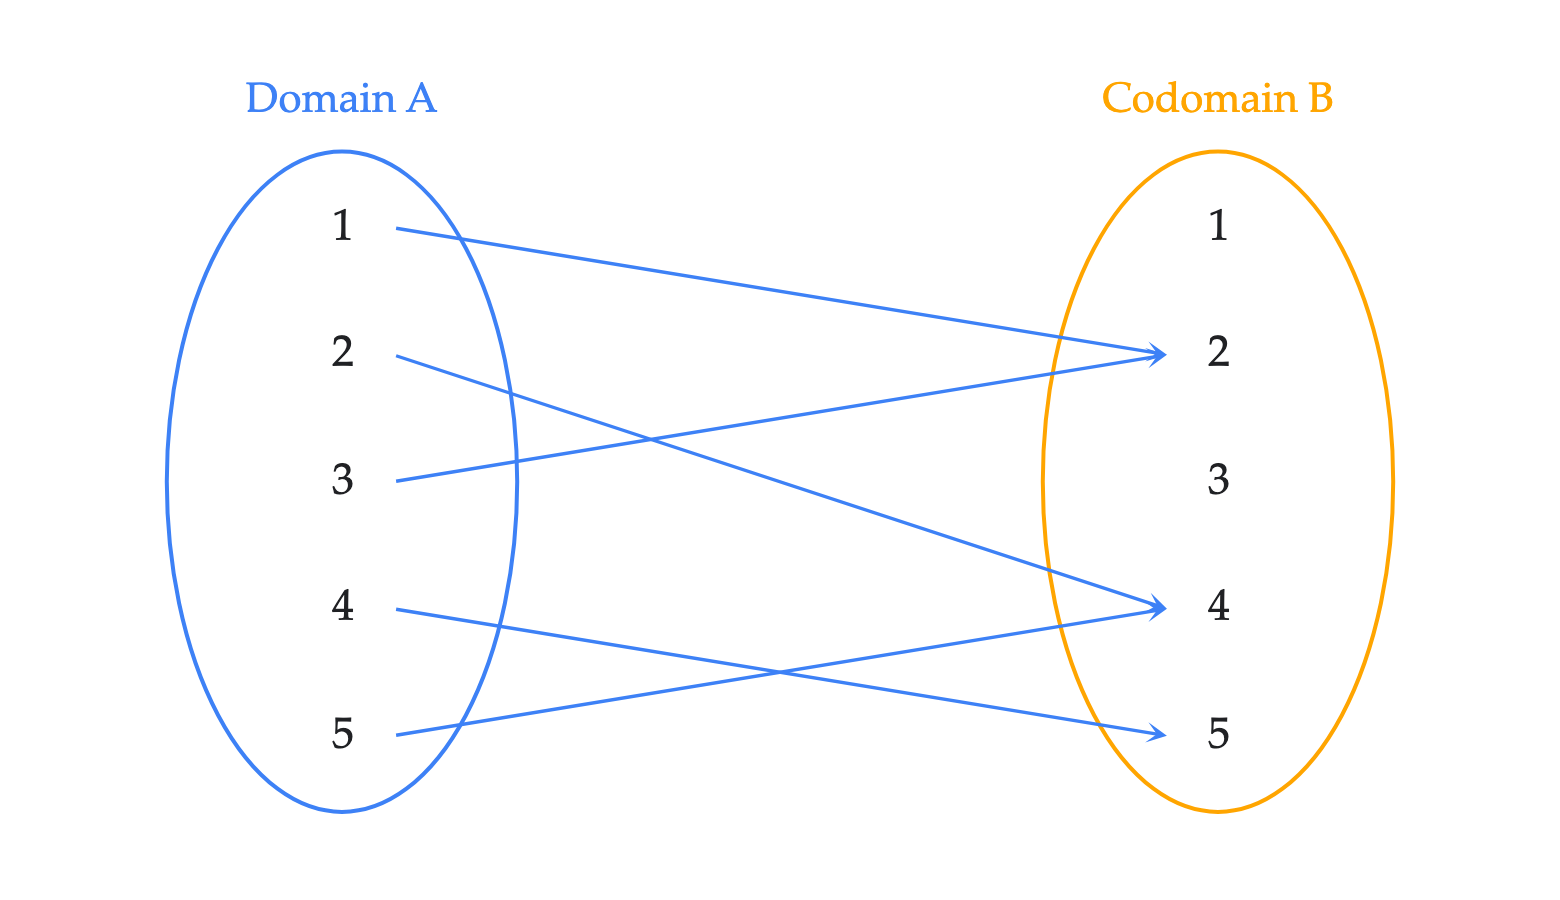

In [2]:
save_figure(mapping(), 'function-arrows', 'Two sets, each containing 1 through 5. Arrows show 1 to 2, 2 to 4, 3 to 2, 4 to 5, and 5 to 4.', 'Every input has exactly one arrow leaving it. Some outputs have more than one arrow pointing to them; others have none.')

Notice that neither $1$ nor $3$ is ever produced, even though both belong to $B$. **Not every element of the codomain needs to be pointed to.** We will see this happen with vectors, too.

### A rule instead of a table

We could define a different function $g:A\to B$ by the rule $g(a)=6-a$. Then $g(1)=5$, $g(2)=4$, and so on. A table and a rule are two ways of telling us what a function does.

### Vectors as inputs

Now let's try a function whose inputs and outputs are vectors:

$$F:\mathbb R^2\to\mathbb R^2,\qquad
F\left(\begin{bmatrix}x\\y\end{bmatrix}\right)=\begin{bmatrix}x+2\\y\end{bmatrix}.$$

In words, **add 2 to the first entry and leave the second entry alone**. For example,

$$F\left(\begin{bmatrix}3\\-1\end{bmatrix}\right)=\begin{bmatrix}5\\-1\end{bmatrix},\qquad
F\left(\begin{bmatrix}0\\0\end{bmatrix}\right)=\begin{bmatrix}2\\0\end{bmatrix}.$$

The domain is $\mathbb R^2$ and the codomain is $\mathbb R^2$. There are two entries in each input, but the whole vector is **one input** to $F$.

We can think of $F$ as moving every point two units to the right. That certainly transforms our vectors. But is it the kind of transformation we can describe using a matrix?


---

## Linear transformations

**Linear transformations** are a very specific type of function. The two properties in the definition should look familiar from [Chapter 3.2](03-02.ipynb).

:::{note} Definition: Linear transformation
A function $T$ is a **linear transformation** from $\mathbb R^d$ to $\mathbb R^n$ if it satisfies these two requirements:

1. $T(\vec u+\vec v)=T(\vec u)+T(\vec v)$ for **every** $\vec u,\vec v\in\mathbb R^d$.
2. $T(c\vec v)=cT(\vec v)$ for **every** $\vec v\in\mathbb R^d$ and **every** scalar $c\in\mathbb R$.

It is not necessary that $d=n$.
:::

The first property says that adding two inputs and then applying $T$ gives the same result as applying $T$ to each input and adding the outputs. The second says that scaling an input scales its output by the same amount.

Together, they tell us that

$$T(a\vec u+b\vec v)=aT(\vec u)+bT(\vec v).$$

That is, we can pull the coefficients outside the function, just as we did with matrix-vector multiplication.

### What about functions of one number?

We can think of a real number as a vector with one entry, so functions $\mathbb R\to\mathbb R$ can be linear transformations too. For instance, take $f(x)=3x$. Then

$$f(u+v)=3(u+v)=3u+3v=f(u)+f(v),\qquad f(cu)=3cu=cf(u).$$

Its domain and codomain are both $\mathbb R$, and both algebraic properties hold, so $f$ is a linear transformation.

What about $g(x)=3x+1$? Its graph is a line, but $g$ is **not** a linear transformation! For example,

$$g(1+1)=7,\qquad g(1)+g(1)=4+4=8.$$

The addition property fails; one counterexample is all we need to show $g(x)$ is not a linear transformation. It is an **affine transformation**, which is a "shifted" linear transformation (just as an affine line is a line that doesn't necessarily go through the origin).

### A useful first check

If $T$ is a linear transformation, setting $c=0$ in the scaling property gives

$$T(\vec0)=T(0\vec v)=0T(\vec v)=\vec0.$$

So **every linear transformation sends the zero vector to the zero vector**. Our earlier function $F$, which adds 2 to the first entry, fails this check. It is a function, but it isn't a linear transformation.

Passing this check doesn't automatically make a function a linear transformation. For example, $h(x)=x^2$ sends 0 to 0, but $h(2\cdot1)=4$ while $2h(1)=2$.

:::{tip} Activity 1: Is it a linear transformation?
:class: dropdown

For each function, identify its domain and codomain and decide whether it is a linear transformation. If it is a linear transformation, check the addition and scaling properties using arbitrary inputs. If it isn't, give an example where a property fails.

1. $f:\mathbb R\to\mathbb R$, with $f(x)=-2x$.
2. $g:\mathbb R\to\mathbb R$, with $g(x)=x+4$.
3. $h:\mathbb R\to\mathbb R$, with $h(x)=x^2$.
4. $T:\mathbb R^2\to\mathbb R^2$, with $T\left(\begin{bmatrix}x\\y\end{bmatrix}\right)=\begin{bmatrix}x+y\\x\end{bmatrix}$.
5. $U:\mathbb R^2\to\mathbb R^3$, with $U\left(\begin{bmatrix}x\\y\end{bmatrix}\right)=\begin{bmatrix}x\\y\\x+y\end{bmatrix}$.
6. $V:\mathbb R^2\to\mathbb R^2$, with $V\left(\begin{bmatrix}x\\y\end{bmatrix}\right)=\begin{bmatrix}xy\\y\end{bmatrix}$.

For the functions that are linear transformations, can you find a matrix that gives the same output when multiplied by the input?
:::


---

## Matrices as linear transformations

:::{attention} Important!
**Every linear transformation from $\mathbb R^d$ to $\mathbb R^n$ can be described as a matrix-vector multiplication.**
:::

More precisely, for every linear transformation $T:\mathbb R^d\to\mathbb R^n$, there is a unique $n\times d$ matrix $A$ such that

$$T(\vec x)=A\vec x\qquad\text{for every }\vec x\in\mathbb R^d.$$

Conversely, multiplying by any fixed $n\times d$ matrix defines a linear transformation from $\mathbb R^d$ to $\mathbb R^n$.

Let's see how to find that matrix. The rule

$$T\left(\begin{bmatrix}x\\y\end{bmatrix}\right)=\begin{bmatrix}x+y\\x\end{bmatrix}$$

can be written as

$$T\left(\begin{bmatrix}x\\y\end{bmatrix}\right)
=\begin{bmatrix}1&1\\1&0\end{bmatrix}\begin{bmatrix}x\\y\end{bmatrix}.$$

The first row records how to compute the first output entry: $1x+1y$. The second records how to compute the second output entry: $1x+0y$.

Here are two more examples:

$$\begin{aligned}
\begin{bmatrix}x\\y\end{bmatrix}\longmapsto\begin{bmatrix}x\\y\\x+y\end{bmatrix}
&\qquad\text{uses}\qquad \begin{bmatrix}1&0\\0&1\\1&1\end{bmatrix},\\[6pt]
\begin{bmatrix}x\\y\\z\end{bmatrix}\longmapsto\begin{bmatrix}x-z\\2y\end{bmatrix}
&\qquad\text{uses}\qquad \begin{bmatrix}1&0&-1\\0&2&0\end{bmatrix}.
\end{aligned}$$

Notice the shapes: $3\times2$ in the first example, $2\times3$ in the second. Each input entry needs a column, and each output entry needs a row.

### A mystery matrix

I'm thinking of a $2\times2$ matrix $A$. I won't tell you its entries, but I'll give you two clues:

$$A\begin{bmatrix}1\\0\end{bmatrix}=\begin{bmatrix}2\\-1\end{bmatrix},\qquad
A\begin{bmatrix}0\\1\end{bmatrix}=\begin{bmatrix}3\\4\end{bmatrix}.$$

**Can you identify all of $A$ from just these two outputs?** Take a moment to think about what each multiplication tells you.

Write the unknown matrix as $A=\begin{bmatrix}a&b\\c&d\end{bmatrix}$. Then

$$\begin{bmatrix}a&b\\c&d\end{bmatrix}\begin{bmatrix}1\\0\end{bmatrix}
=\begin{bmatrix}a\\c\end{bmatrix},\qquad
\begin{bmatrix}a&b\\c&d\end{bmatrix}\begin{bmatrix}0\\1\end{bmatrix}
=\begin{bmatrix}b\\d\end{bmatrix}.$$

The first input selects the first column: one copy of that column and zero copies of the other. The second input selects the second column. So the two clues reveal every entry:

$$A=\begin{bmatrix}2&3\\-1&4\end{bmatrix}.$$

Recall that $\vec e_1=\begin{bmatrix}1\\0\end{bmatrix}$ and $\vec e_2=\begin{bmatrix}0\\1\end{bmatrix}$ are just our standard basis vectors. **Sending these two vectors through a matrix reveals its two columns.**

### Why do two outputs determine every output?

In $\mathbb R^2$, every vector can be written using the standard basis vectors:

$$\begin{bmatrix}x\\y\end{bmatrix}
=x\underbrace{\begin{bmatrix}1\\0\end{bmatrix}}_{\vec e_1}
+y\underbrace{\begin{bmatrix}0\\1\end{bmatrix}}_{\vec e_2}.$$

If $T$ is a linear transformation, then

$$T\left(\begin{bmatrix}x\\y\end{bmatrix}\right)
=xT(\vec e_1)+yT(\vec e_2).$$

This is a linear combination of two fixed vectors. We already know how to write that as a matrix-vector product: put the two vectors into the columns of a matrix!

The same argument works in $\mathbb R^d$:

$$T(\vec x)=x_1T(\vec e_1)+\cdots+x_dT(\vec e_d).$$

:::{note} Finding the matrix
To find the matrix of a linear transformation, apply it to the standard basis vectors and put the resulting outputs into columns:

$$A=\begin{bmatrix}|&|&&|\\T(\vec e_1)&T(\vec e_2)&\cdots&T(\vec e_d)\\|&|&&|\end{bmatrix}.$$

**Column $j$ tells us where $\vec e_j$ goes.** These columns are forced by $T$, which is why there is only one such matrix.
:::

For example, suppose a linear transformation satisfies

$$T(\vec e_1)=\begin{bmatrix}2\\-1\end{bmatrix},\qquad T(\vec e_2)=\begin{bmatrix}3\\4\end{bmatrix}.$$

Without knowing anything else about $T$, we can write

$$A=\begin{bmatrix}2&3\\-1&4\end{bmatrix},\qquad
T\left(\begin{bmatrix}3\\-2\end{bmatrix}\right)
=3\begin{bmatrix}2\\-1\end{bmatrix}-2\begin{bmatrix}3\\4\end{bmatrix}
=\begin{bmatrix}0\\-11\end{bmatrix}.$$

Just two outputs determined what happens to every vector in $\mathbb R^2$. In [Chapter 3.4](03-04.ipynb), we'll use this idea to understand what different matrices do geometrically.
